In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
import pickle
from matplotlib.colors import ListedColormap

In [27]:
### nice plots

import matplotlib as matp

matp.rcParams['mathtext.fontset'] = 'stix'
matp.rcParams['font.family'] = 'STIXGeneral'
markers = ["^", "o", "s"]

colormap = plt.cm.plasma.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, 3))) 

sns.set_palette("pastel")
colors = sns.color_palette("pastel", n_colors=3)

## Read data for analysis

In [3]:
## MNPP

class Datas():
    def __init__(self, bits_idx_list, n_temp_scalers, M_strats, n_eta_runs, n_samples_SA = 128):
        Ns = np.arange(3, 9)
        vseeds = np.arange(42, 142)
        self.P = 3
        self.Ns = Ns[bits_idx_list]
        self.bits = Ns[bits_idx_list] * self.P
        self.vseeds = vseeds
        self.n_vseeds = len(vseeds)
        self.M_strategies = M_strats # index: 0->"feasibility", 1->"optimality"
        self.temperature_scalers = [1, 10, 100]
        self.temperature_base = 1e4
        self.temperatures_labels = ["$10^4$", "$10^5$", "$10^6$"] # = temp_base * temp_scalers
        self.Gibbs_samples = 1000

        self.M_star = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.M_L1 = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_required = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_guaranteed = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_effective = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.temperature = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers))
        self.E_f = np.ndarray((len(bits_idx_list), len(vseeds)))


# change last_Nidx to extend your dataset as you collect more data

last_Nidx = 5
Ns = np.arange(3, 9)
N_idxs = np.arange(last_Nidx+1)
n_temp_scalers = 3
M_strategies = ["feasibility", "optimality"]
n_eta_runs = 3
data = Datas(N_idxs, n_temp_scalers, M_strategies, n_eta_runs)

directory = "../data/Gibbs_NPP/"

for N_idx in N_idxs: # if N_idxs start from 0. Else, write "for N_idx_idx, N_idx in enumerate(N_idxs):"
    filename = directory + f"results-N={Ns[N_idx]}_P=3.txt"
    file = open(filename, "rb")
    D = pickle.load(file)
    file.close()

    assert len(D.keys()) == len(data.vseeds)
    for seed_idx, seed in enumerate(D):
        data.E_f[N_idx, seed_idx] = D[seed]["E_f"]

        assert len(D[seed].keys()) == n_temp_scalers + 1 # the +1 is for E_f
        for temp_idx, temp_scaler in enumerate(list(D[seed])[1:]):
            data.temperature[N_idx, seed_idx, temp_idx] = D[seed][temp_scaler]["temperature"]

            assert len(D[seed][temp_scaler].keys()) == len(M_strategies) + 1  # the +1 is for temperature
            for M_strat_idx, M_strat in enumerate(list(D[seed][temp_scaler])[1:]):
                assert len(D[seed][temp_scaler][M_strat].keys()) == n_eta_runs
                for eta_run_idx, eta_req in enumerate(D[seed][temp_scaler][M_strat]):
                    data.M_star[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_star"]
                    data.M_L1[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_L1"]
                    data.eta_required[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_required"]
                    data.eta_guaranteed[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_guaranteed"]
                    data.eta_effective[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_effective"]

data_MNPP = data

In [ ]:
### TSP rand
class Datas():
    def __init__(self, bits_idx_list, n_temp_scalers, M_strats, n_eta_runs, n_samples_SA = 128):
        N_cities = np.arange(2, 6)
        vseeds = np.arange(42, 142)
        self.Nc = N_cities[bits_idx_list]
        self.bits = N_cities[bits_idx_list]**2
        self.vseeds = vseeds
        self.n_vseeds = len(vseeds)
        self.M_strategies = M_strats # index: 0->"feasibility", 1->"optimality"
        self.temperature_scalers = [1, 10, 100]
        self.temperature_base = 1e4
        self.temperatures_labels = ["$10^4$", "$10^5$", "$10^6$"] # = temp_base * temp_scalers
        self.Gibbs_samples = 1000

        self.M_star = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.M_L1 = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_required = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_guaranteed = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_effective = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.temperature = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers))
        self.E_f = np.ndarray((len(bits_idx_list), len(vseeds)))

# change last_Nidx to extend your dataset as you collect more data

last_Nidx = 3
N_idxs = np.arange(last_Nidx+1)
n_temp_scalers = 3
M_strategies = ["feasibility", "optimality"]
n_eta_runs = 3
data = Datas(N_idxs, n_temp_scalers, M_strategies, n_eta_runs)

directory = "../data/Gibbs_TSP_rand/"

for N_idx in N_idxs: # if N_idxs start from 0. Else, write "for N_idx_idx, N_idx in enumerate(N_idxs):"
    filename = directory + f"results-Nc={data.Nc[N_idx]}.txt"
    file = open(filename, "rb")
    D = pickle.load(file)
    file.close()

    assert len(D.keys()) == len(data.vseeds)
    for seed_idx, seed in enumerate(D):
        data.E_f[N_idx, seed_idx] = D[seed]["E_f"]

        assert len(D[seed].keys()) == n_temp_scalers + 1 # the +1 is for E_f
        for temp_idx, temp_scaler in enumerate(list(D[seed])[1:]):
            data.temperature[N_idx, seed_idx, temp_idx] = D[seed][temp_scaler]["temperature"]

            assert len(D[seed][temp_scaler].keys()) == len(M_strategies) + 1  # the +1 is for temperature
            for M_strat_idx, M_strat in enumerate(list(D[seed][temp_scaler])[1:]):
                assert len(D[seed][temp_scaler][M_strat].keys()) == n_eta_runs
                for eta_run_idx, eta_req in enumerate(D[seed][temp_scaler][M_strat]):
                    data.M_star[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_star"]
                    data.M_L1[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_L1"]
                    data.eta_required[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_required"]
                    data.eta_guaranteed[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_guaranteed"]
                    data.eta_effective[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_effective"]

data_TSP_r = data

In [5]:
### TSP circle

class Datas():
    def __init__(self, bits_idx_list, n_temp_scalers, M_strats, n_eta_runs, n_samples_SA = 128):
        N_cities = np.arange(2, 6)
        vseeds = np.arange(42, 43)
        self.Nc = N_cities[bits_idx_list]
        self.bits = N_cities[bits_idx_list]**2
        self.vseeds = vseeds
        self.n_vseeds = len(vseeds)
        self.M_strategies = M_strats # index: 0->"feasibility", 1->"optimality"
        self.temperature_scalers = [1, 10, 100]
        self.temperature_base = 1e4
        self.temperatures_labels = ["$10^4$", "$10^5$", "$10^6$"] # = temp_base * temp_scalers
        self.Gibbs_samples = 1000

        self.M_star = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.M_L1 = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_required = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_guaranteed = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_effective = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.temperature = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers))
        self.E_f = np.ndarray((len(bits_idx_list), len(vseeds)))



# change last_Nidx to extend your dataset as you collect more data

last_Nidx = 3
N_idxs = np.arange(last_Nidx+1)
n_temp_scalers = 3
M_strategies = ["feasibility", "optimality"]
n_eta_runs = 3
data = Datas(N_idxs, n_temp_scalers, M_strategies, n_eta_runs)

directory = "../data/Gibbs_TSP_circle/"

for N_idx in N_idxs: # if N_idxs start from 0. Else, write "for N_idx_idx, N_idx in enumerate(N_idxs):"
    filename = directory + f"results-Nc={data.Nc[N_idx]}.txt"
    file = open(filename, "rb")
    D = pickle.load(file)
    file.close()

    assert len(D.keys()) == len(data.vseeds)
    for seed_idx, seed in enumerate(D):
        data.E_f[N_idx, seed_idx] = D[seed]["E_f"]

        assert len(D[seed].keys()) == n_temp_scalers + 1 # the +1 is for E_f
        for temp_idx, temp_scaler in enumerate(list(D[seed])[1:]):
            data.temperature[N_idx, seed_idx, temp_idx] = D[seed][temp_scaler]["temperature"]

            assert len(D[seed][temp_scaler].keys()) == len(M_strategies) + 1  # the +1 is for temperature
            for M_strat_idx, M_strat in enumerate(list(D[seed][temp_scaler])[1:]):
                assert len(D[seed][temp_scaler][M_strat].keys()) == n_eta_runs
                for eta_run_idx, eta_req in enumerate(D[seed][temp_scaler][M_strat]):
                    data.M_star[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_star"]
                    data.M_L1[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_L1"]
                    data.eta_required[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_required"]
                    data.eta_guaranteed[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_guaranteed"]
                    data.eta_effective[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_effective"]

data_TSP_c = data

In [6]:
### PO

class Datas():
    def __init__(self, bits_idx_list, n_temp_scalers, M_strats, n_eta_runs):
        N_stocks = np.arange(2, 9)
        self.w = 3
        self.directory = "PO_small"
        vseeds = range(42, 9943, 100)

        self.Ns = N_stocks[bits_idx_list]
        self.bits = self.Ns[bits_idx_list] * self.w
        self.vseeds = vseeds
        self.n_vseeds = len(vseeds)
        self.M_strategies = M_strats # index: 0->"feasibility", 1->"optimality"
        self.temperature_scalers = [1, 10, 100]
        self.temperature_base = 1e4
        self.temperatures_labels = ["$10^4$", "$10^5$", "$10^6$"] # = temp_base * temp_scalers
        self.Gibbs_samples = 1000

        self.M_star = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.M_L1 = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_required = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_guaranteed = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_effective = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.temperature = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers))
        self.E_f = np.ndarray((len(bits_idx_list), len(vseeds)))


# change last_Nidx to extend your dataset as you collect more data

last_Nidx = 6
N_stocks = np.arange(2, 9)
N_idxs = np.arange(last_Nidx+1)
n_temp_scalers = 3
M_strategies = ["feasibility", "optimality"]
n_eta_runs = 3
data = Datas(N_idxs, n_temp_scalers, M_strategies, n_eta_runs)

directory = "../data/Gibbs_PO/"

for N_idx in N_idxs: # if N_idxs start from 0. Else, write "for N_idx_idx, N_idx in enumerate(N_idxs):"
    filename = directory + f"results-N={N_stocks[N_idx]}_w={data.w}.txt"
    file = open(filename, "rb")
    D = pickle.load(file)
    file.close()

    assert len(D.keys()) == len(data.vseeds)
    for seed_idx, seed in enumerate(D):
        data.E_f[N_idx, seed_idx] = D[seed]["E_f"]

        assert len(D[seed].keys()) == n_temp_scalers + 1 # the +1 is for E_f
        for temp_idx, temp_scaler in enumerate(list(D[seed])[1:]):
            data.temperature[N_idx, seed_idx, temp_idx] = D[seed][temp_scaler]["temperature"]

            assert len(D[seed][temp_scaler].keys()) == len(M_strategies) + 1  # the +1 is for temperature
            for M_strat_idx, M_strat in enumerate(list(D[seed][temp_scaler])[1:]):
                assert len(D[seed][temp_scaler][M_strat].keys()) == n_eta_runs
                for eta_run_idx, eta_req in enumerate(D[seed][temp_scaler][M_strat]):
                    data.M_star[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_star"]
                    data.M_L1[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_L1"]
                    data.eta_required[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_required"]
                    data.eta_guaranteed[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_guaranteed"]
                    data.eta_effective[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_effective"]
                    

data_PO = data

## $\eta_{eff}(n_{bits})$

In [25]:
def plot_marker_whiskers(ax, data, indexes):
    draw_lower_whiskers, draw_upper_whiskers = True, False

    temp_idx, M_strat_idx, eta_run_idx = indexes
    eta_r = data.eta_required[:, 0, temp_idx, M_strat_idx, eta_run_idx]
    y = np.mean( data.eta_effective[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
    ax.plot(data.bits, y, linestyle="None", marker = markers[temp_idx], markersize = 5, color = discr_colors.colors[eta_run_idx], markeredgecolor="black")

    # compute where to draw whiskers
    condition_eff =  y  <  eta_r
    condition_gua =  np.mean(data.eta_guaranteed[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)  <  eta_r
    mask_whisk = np.logical_and(condition_gua, condition_eff)
    # compute whiskers lengths from eta_guaranteed
    whisk = y[mask_whisk] - np.mean(data.eta_guaranteed[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)[mask_whisk]
    whisk_down = np.where(whisk > 0, whisk, 0)
    whisk_up = np.where(whisk < 0, -whisk, 0)

    capsize = .5
    cap_thickness = 1.5    
    # draw only lower whiskers manually
    if draw_lower_whiskers:
        for xi, yi, yd in zip(data.bits[mask_whisk], y[mask_whisk], whisk_down):
            ax.vlines(xi, yi - yd, yi, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
            ax.hlines(yi - yd, xi - capsize, xi + capsize, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
    # draw only upper whiskers manually
    if draw_upper_whiskers:
        for xi, yi, yd in zip(data.bits[mask_whisk], y[mask_whisk], whisk_up):
            ax.vlines(xi, yi, yi + yd, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
            ax.hlines(yi + yd, xi - capsize, xi + capsize, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
    return

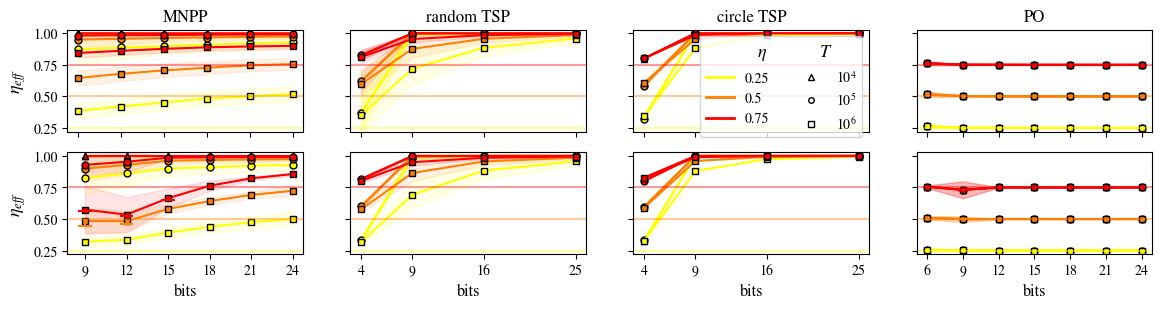

In [32]:
markers = ["^", "o", "s"]
colormap = plt.cm.autumn.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, n_eta_runs)))

scaler = 2 # with scaler = 2, the sizes below refer to (half the) pt
size_ticks = 5*scaler
size_label = 6.5*scaler
size_labelx = size_label*.9
size_title = 6*scaler
size_marker = 2*scaler

fig = plt.figure(figsize=(7*scaler,1.46*scaler))

for idx_bench, data in enumerate([data_MNPP, data_TSP_r, data_TSP_c, data_PO]):
    for M_strat_idx in [0,1]:
        ax = fig.add_subplot(2,4, idx_bench+1 + M_strat_idx*4)
        if idx_bench == 0:
            ax.set_ylabel(r'$\eta_{eff}$', fontsize = size_label)
        ax.set_yticks([.25, .5, .75, 1])
        ax.set_xticks(data.bits)
        if M_strat_idx == 0:
            ax.tick_params(axis='x', labelbottom=False)
        else:
            ax.tick_params(axis='x', labelsize=size_ticks)
        if idx_bench == 0:
            ax.tick_params(axis='y', labelsize=size_ticks) 
        else:
            ax.tick_params(axis='y', labelleft=False) 
        ax.set_ylim(.22, 1.03)
        for temp_idx in range(n_temp_scalers):
            for eta_run_idx in np.arange(n_eta_runs):
                y = np.mean( data.eta_effective[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
                y_std = np.std( data.eta_effective[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
                # lines and shades
                ax.plot(data.bits, y, "-", color = discr_colors.colors[eta_run_idx],
                                label=str(data.eta_required[0, 0, 0, 0, eta_run_idx]) + f" ; {data.temperature_scalers[temp_idx]}")
                ax.fill_between(data.bits, y - y_std, y + y_std, color = discr_colors.colors[eta_run_idx], alpha=.1)
                # dots 
                plot_marker_whiskers(ax, data, (temp_idx, M_strat_idx, eta_run_idx))    
        if M_strat_idx == 0:
            if idx_bench == 0:
                ax.set_title("MNPP", fontsize = size_title)
            elif idx_bench == 1:
                ax.set_title("random TSP", fontsize = size_title)
            elif idx_bench == 2:
                ax.set_title("circle TSP", fontsize = size_title)
            elif idx_bench == 3:
                ax.set_title("PO", fontsize = size_title)

            if idx_bench == 2:
                # ---- Concise legend ----
                eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, data_TSP_c.eta_required[0,0,0,0])]
                temp_handles = [Line2D([0], [0], color="w", markersize = size_marker,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, data_TSP_c.temperatures_labels)]
                all_handles = eta_handles + temp_handles
                all_labels  = [h.get_label() for h in all_handles]
                ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta$            $T$", title_fontsize=size_label, fontsize=size_ticks, loc="best", ncol=2)
                # --------
        else:
            ax.set_xlabel(r'bits', fontsize = size_labelx)
        eta_req_tmp = [.25, .5, .75]
        for i in range(len(eta_req_tmp)):
            ax.axhline(eta_req_tmp[i], color = discr_colors.colors[i], alpha = 0.4)
plt.show()

# fig.savefig(f"../plots_paper/eta_eff_big/Gibbs_2.pdf", bbox_inches='tight', format="pdf")